In [1]:
!pip install gradio transformers torch pillow

In [2]:
import gradio as gr
import torch
from PIL import Image
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
model_path = "/content/drive/MyDrive/SI26-urdu-ocr-model"

processor = TrOCRProcessor.from_pretrained(model_path)
model = VisionEncoderDecoderModel.from_pretrained(model_path)

model.eval()

Loading weights:   0%|          | 0/480 [00:00<?, ?it/s]

VisionEncoderDecoderModel(
  (encoder): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (layers): ModuleList(
      (0-11): 12 x ViTLayer(
        (attention): ViTAttention(
          (q_proj): Linear(in_features=768, out_features=768, bias=False)
          (k_proj): Linear(in_features=768, out_features=768, bias=False)
          (v_proj): Linear(in_features=768, out_features=768, bias=False)
          (o_proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (layernorm_before): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (layernorm_after): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (mlp): ViTMLP(
          (activation_fn): GELUActivation()
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (fc2): Linear(in_features=30

In [4]:
print("Processor loaded:", type(processor))
print("Model loaded:", type(model))

Processor loaded: <class 'transformers.models.trocr.processing_trocr.TrOCRProcessor'>
Model loaded: <class 'transformers.models.vision_encoder_decoder.modeling_vision_encoder_decoder.VisionEncoderDecoderModel'>


In [5]:
def extract_urdu_text(image):

    if image is None:
        return "Please upload an image."

    pixel_values = processor(image, return_tensors="pt").pixel_values

    with torch.no_grad():
        generated_ids = model.generate(pixel_values)

    text = processor.batch_decode(
        generated_ids,
        skip_special_tokens=True
    )[0]

    if text.strip() == "":
        return "Could not extract text."

    return text

In [21]:
interface = gr.Interface(
    fn=extract_urdu_text,
    inputs=gr.Image(type="pil", label="Upload Urdu Image"),
    outputs=gr.Textbox(label="Extracted Urdu Text"),
    title="Urdu OCR - Code Saviours SI-26",
    description="Upload an Urdu image and extract Urdu text."
)

interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c1a366185234fda5dd.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Prediction: REPLING PLUS,FILTO


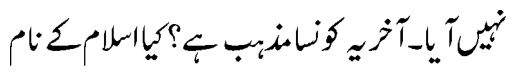

In [14]:
from PIL import Image
import matplotlib.pyplot as plt
import torch
import os

image_path = "/content/drive/MyDrive/Colab Notebooks/data/processed/100.png"

image = Image.open(image_path).convert("RGB")

plt.imshow(image)
plt.axis("off")

pixel_values = processor(image, return_tensors="pt").pixel_values

with torch.no_grad():
    generated_ids = model.generate(pixel_values)

prediction = processor.batch_decode(
    generated_ids,
    skip_special_tokens=True
)[0]

print("Prediction:", prediction)

In [15]:
def extract_urdu_text(image):
    if image is None:
        return "Please upload an image."

    pixel_values = processor(image, return_tensors="pt").pixel_values

    with torch.no_grad():
        generated_ids = model.generate(
            pixel_values,
            max_new_tokens=128
        )

    text = processor.batch_decode(
        generated_ids,
        skip_special_tokens=True
    )[0]

    return text